# Hotel Booking Cancellation Prediction

# Part A — Exploratory Data Analysis

In [7]:
%pip install matplotlib seaborn scipy scikit-learn xgboost lightgbm joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, shapiro
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


Matplotlib is building the font cache; this may take a moment.


### LOAD DATA

In [9]:
df = pd.read_csv("hotel_bookings.csv")
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head(3)


Dataset shape: 119,390 rows, 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


### TARGET VARIABLE

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


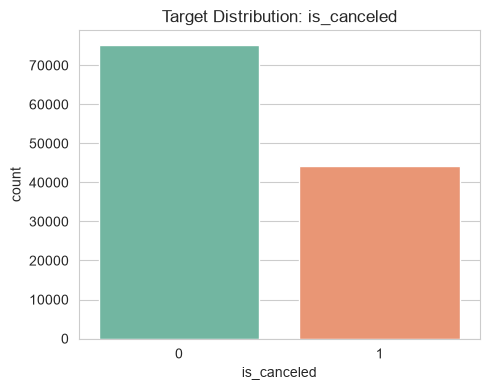

In [10]:
print(df["is_canceled"].value_counts())
print(df["is_canceled"].value_counts(normalize=True) * 100)

plt.figure(figsize=(5, 4))
sns.countplot(x="is_canceled", data=df, hue="is_canceled", palette="Set2", legend=False)
plt.title("Target Distribution: is_canceled")
plt.tight_layout()
plt.show()


### MISSING VALUES

In [11]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)
print(missing_summary)

          missing_count  missing_pct
company          112593    94.306893
agent             16340    13.686238
country             488     0.408744
children              4     0.003350


agent
False    0.390044
True     0.246634
Name: is_canceled, dtype: float64
company
False    0.175224
True     0.382200
Name: is_canceled, dtype: float64


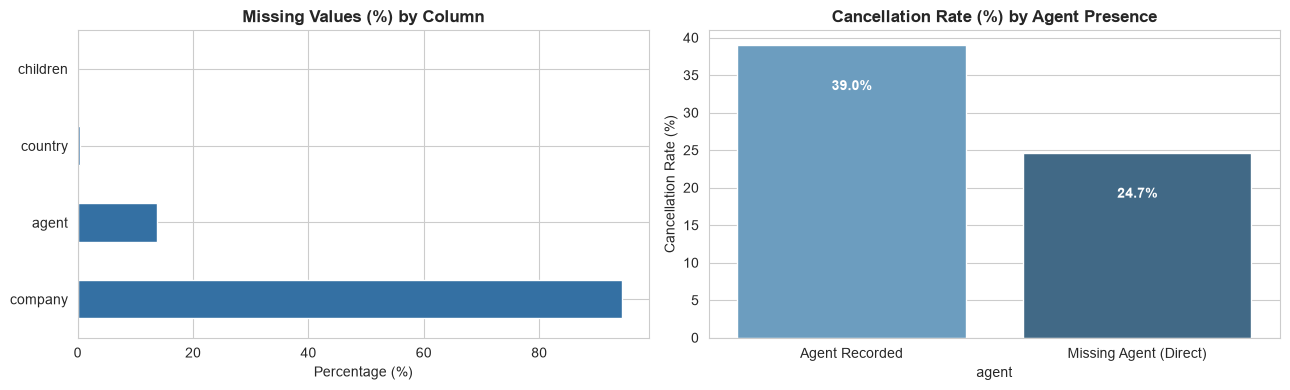

In [12]:

print(df.groupby(df["agent"].isna())["is_canceled"].mean())
print(df.groupby(df["company"].isna())["is_canceled"].mean())


# Missingness and cancellation rate by agent presence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# 1. Missingness percentage
missing_summary.plot(kind="barh", y="missing_pct", ax=ax1, color="#3470a3", legend=False)
ax1.set_title("Missing Values (%) by Column", fontweight="bold")
ax1.set_xlabel("Percentage (%)")

# 2. Cancellation rate by Agent presence
agent_canc = df.groupby(df["agent"].isna().map({True: "Missing Agent (Direct)", False: "Agent Recorded"}))["is_canceled"].mean() * 100
sns.barplot(x=agent_canc.index, y=agent_canc.values, hue=agent_canc.index, palette="Blues_d", legend=False, ax=ax2)
ax2.set_title("Cancellation Rate (%) by Agent Presence", fontweight="bold")
ax2.set_ylabel("Cancellation Rate (%)")
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 6),
                 ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()



### HIDDEN MISSING VALUES (placeholder categories)

In [13]:
cat_cols = df.select_dtypes(exclude="number").columns
placeholder_terms = ["Undefined", "Unknown", "?", "None", "-", ""]
placeholder_rows = []
for col in cat_cols:
    for term in placeholder_terms:
        count = (df[col].astype(str).str.strip() == term).sum()
        if count > 0:
            placeholder_rows.append({"Column": col, "Placeholder": term, "Count": count,
                                      "Percentage (%)": round(count / len(df) * 100, 4)})
print(pd.DataFrame(placeholder_rows))


                 Column Placeholder  Count  Percentage (%)
0                  meal   Undefined   1169          0.9791
1        market_segment   Undefined      2          0.0017
2  distribution_channel   Undefined      5          0.0042


### DUPLICATE RECORDS

In [14]:
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates:,} ({n_duplicates / len(df) * 100:.2f}%)")

dup_group_sizes = df.value_counts(dropna=False)
dup_group_sizes = dup_group_sizes[dup_group_sizes > 1]
print(f"Duplicate groups: {len(dup_group_sizes)}, largest group: {dup_group_sizes.max()}")

dup_segments = df[df.duplicated(keep=False)]["market_segment"].value_counts(normalize=True) * 100
print(dup_segments)


Duplicate rows: 31,994 (26.80%)
Duplicate groups: 8171, largest group: 180
market_segment
Groups           41.610855
Offline TA/TO    30.399602
Online TA        20.587576
Corporate         3.669862
Direct            3.498070
Complementary     0.186730
Aviation          0.047305
Name: proportion, dtype: float64


### UNIVARIATE - NUMERIC

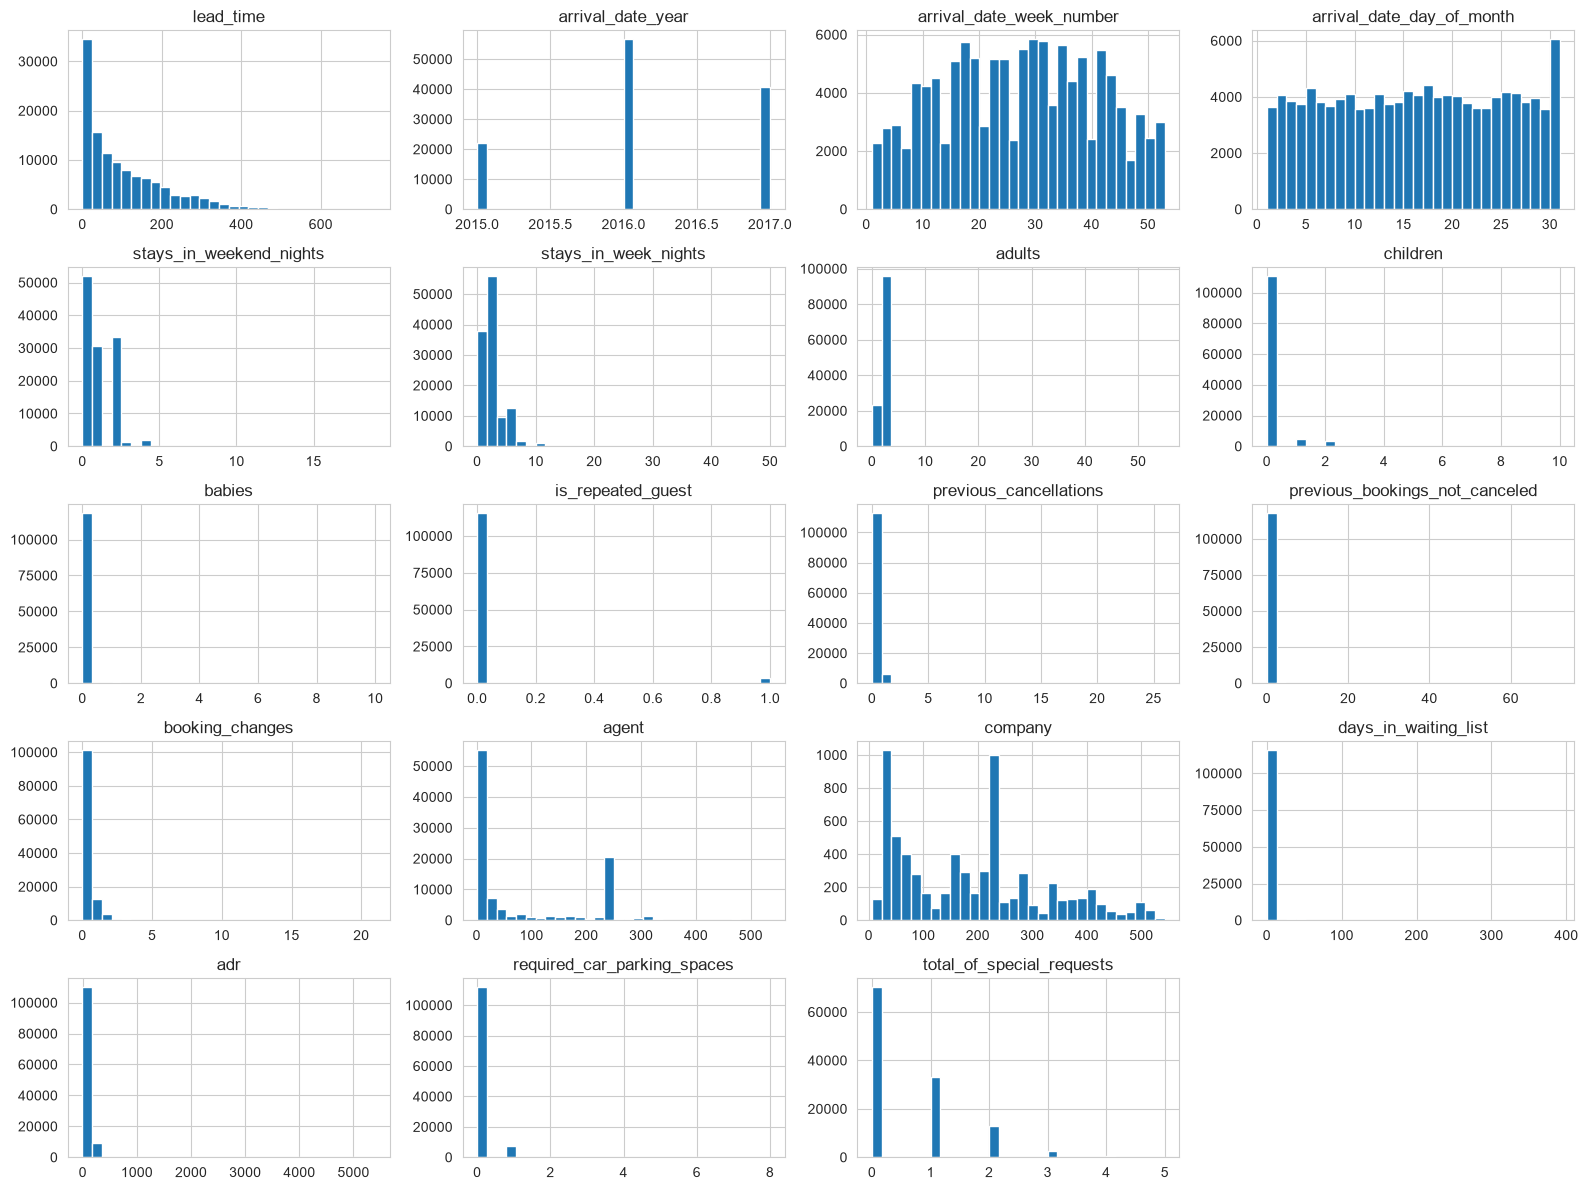

In [15]:
numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c != "is_canceled"]
df[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()


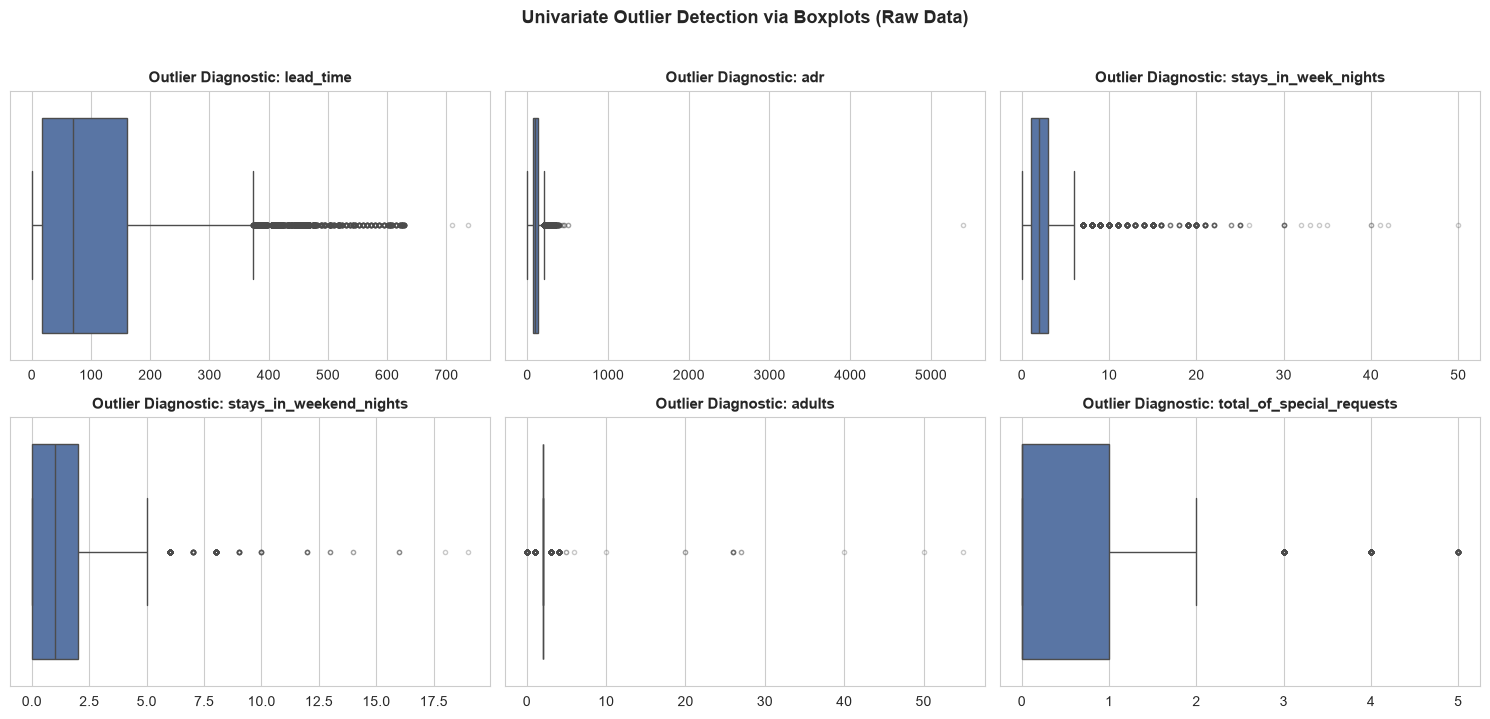

In [16]:
# Boxplots of key numeric columns (outlier check)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
key_num_cols = ["lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights", "adults", "total_of_special_requests"]

for ax, col in zip(axes.flatten(), key_num_cols):
    sns.boxplot(x=df[col], ax=ax, color="#4c72b0", flierprops=dict(marker='o', markersize=3, alpha=0.3, color='crimson'))
    ax.set_title(f"Outlier Diagnostic: {col}", fontsize=11, fontweight="bold")
    ax.set_xlabel("")

plt.suptitle("Univariate Outlier Detection via Boxplots (Raw Data)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### SKEWNESS / NORMALITY TESTS

In [17]:
skew_rows = []
for col in numeric_cols:
    sample = df[col].dropna()
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    stat, p_value = shapiro(sample)
    skew_rows.append({"Feature": col, "Skewness": round(df[col].skew(), 3),
                       "Shapiro_p": round(p_value, 5),
                       "Normal (p>0.05)": p_value > 0.05})
skew_df = pd.DataFrame(skew_rows)
print(skew_df)


                           Feature  Skewness  Shapiro_p  Normal (p>0.05)
0                        lead_time     1.347        0.0            False
1                arrival_date_year    -0.233        0.0            False
2         arrival_date_week_number    -0.010        0.0            False
3        arrival_date_day_of_month    -0.002        0.0            False
4          stays_in_weekend_nights     1.380        0.0            False
5             stays_in_week_nights     2.862        0.0            False
6                           adults    18.318        0.0            False
7                         children     4.113        0.0            False
8                           babies    24.647        0.0            False
9                is_repeated_guest     5.326        0.0            False
10          previous_cancellations    24.458        0.0            False
11  previous_bookings_not_canceled    23.540        0.0            False
12                 booking_changes     6.000       

### CHI-SQUARE TESTS (categorical vs target)

In [18]:
cat_test_cols = ["hotel", "meal", "market_segment", "distribution_channel",
                  "reserved_room_type", "deposit_type", "customer_type"]
chi_rows = []
for col in cat_test_cols:
    table = pd.crosstab(df[col], df["is_canceled"])
    chi2, p, dof, exp = chi2_contingency(table)
    chi_rows.append({"Feature": col, "Chi2": round(chi2, 2), "p_value": p,
                      "Significant (p<0.05)": p < 0.05})
chi_df = pd.DataFrame(chi_rows)
print(chi_df)


                Feature      Chi2        p_value  Significant (p<0.05)
0                 hotel   2224.92   0.000000e+00                  True
1                  meal    304.24   1.321235e-64                  True
2        market_segment   8497.22   0.000000e+00                  True
3  distribution_channel   3745.79   0.000000e+00                  True
4    reserved_room_type    647.84  1.121956e-133                  True
5          deposit_type  27677.33   0.000000e+00                  True
6         customer_type   2222.50   0.000000e+00                  True


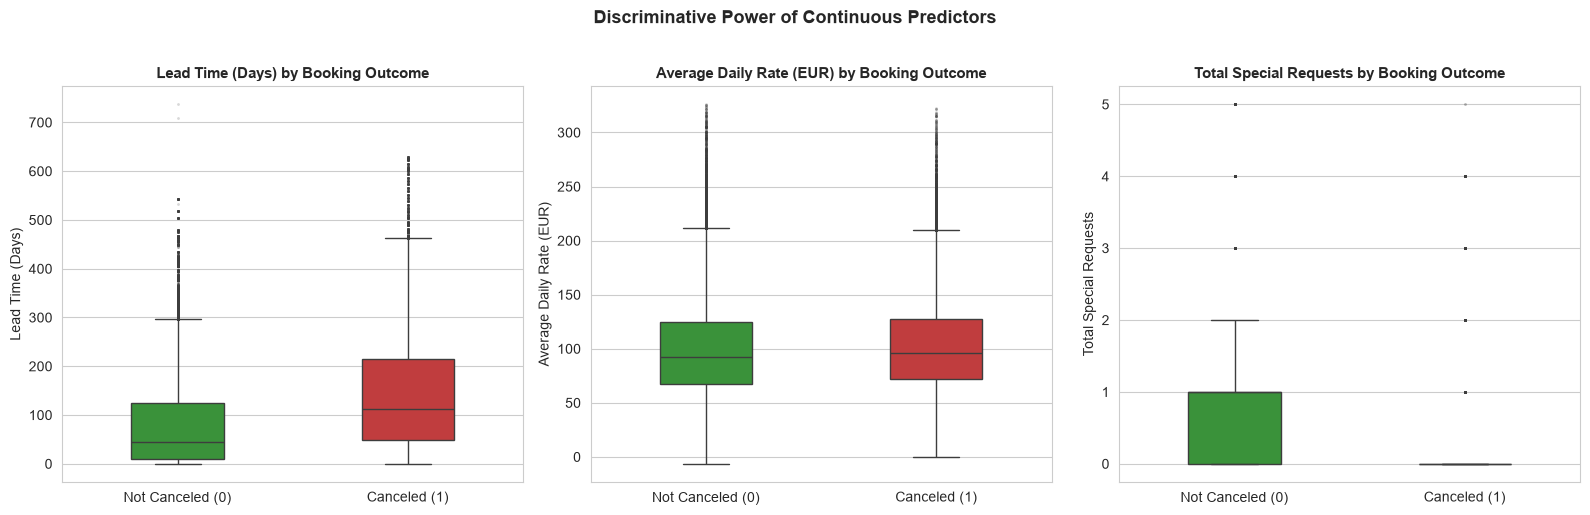

In [19]:
# Bivariate boxplots vs target
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bivariate_cols = [("lead_time", "Lead Time (Days)"), ("adr", "Average Daily Rate (EUR)"), ("total_of_special_requests", "Total Special Requests")]

for ax, (col, label) in zip(axes, bivariate_cols):
    # Filter ADR outlier for clear visualization (data-driven 99.9th percentile)
    adr_viz_cap = df["adr"].quantile(0.999)
    data_plot = df[df["adr"] < adr_viz_cap] if col == "adr" else df
    sns.boxplot(x="is_canceled", y=col, hue="is_canceled", data=data_plot, ax=ax, palette=["#2ca02c", "#d62728"], width=0.4, legend=False,
                flierprops=dict(marker='.', markersize=2, alpha=0.2))
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Not Canceled (0)", "Canceled (1)"])
    ax.set_title(f"{label} by Booking Outcome", fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(label)

plt.suptitle("Discriminative Power of Continuous Predictors", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### BIVARIATE - CANCELLATION RATE BY CATEGORY


hotel:
 hotel
City Hotel      41.726963
Resort Hotel    27.763355
Name: is_canceled, dtype: float64

market_segment:
 market_segment
Undefined        100.000000
Groups            61.062036
Online TA         36.721143
Offline TA/TO     34.316033
Aviation          21.940928
Corporate         18.734655
Direct            15.341901
Complementary     13.055182
Name: is_canceled, dtype: float64

deposit_type:
 deposit_type
Non Refund    99.362446
No Deposit    28.377022
Refundable    22.222222
Name: is_canceled, dtype: float64

customer_type:
 customer_type
Transient          40.746320
Contract           30.961727
Transient-Party    25.429868
Group              10.225303
Name: is_canceled, dtype: float64


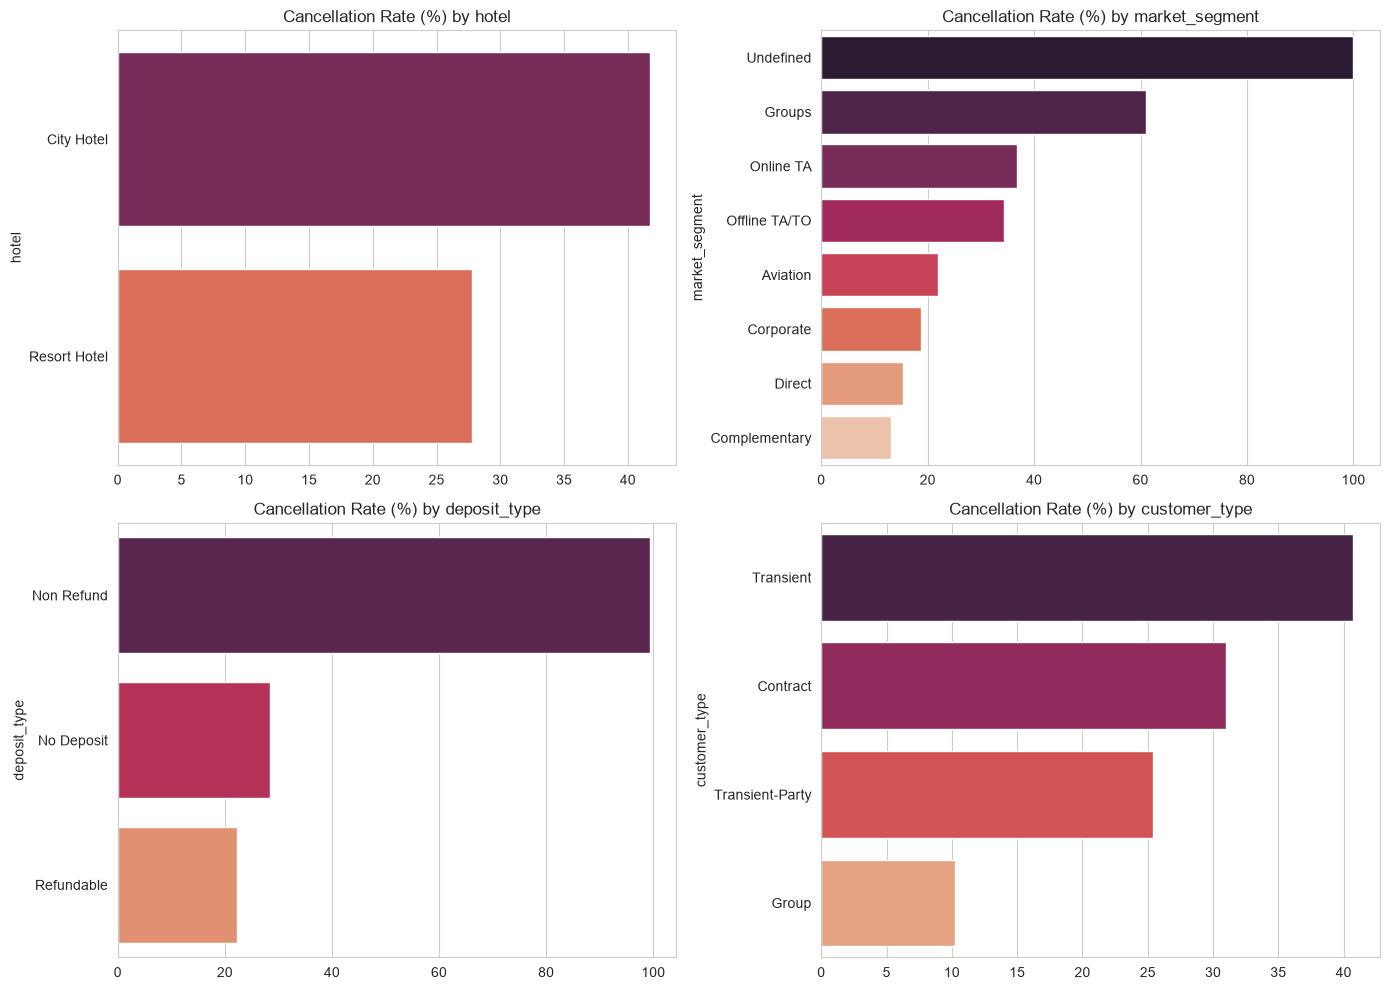

In [20]:
for col in ["hotel", "market_segment", "deposit_type", "customer_type"]:
    rate = df.groupby(col)["is_canceled"].mean().sort_values(ascending=False) * 100
    print(f"\n{col}:\n", rate)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ["hotel", "market_segment", "deposit_type", "customer_type"]):
    rate = df.groupby(col)["is_canceled"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, ax=ax, hue=rate.index, palette="rocket", legend=False)
    ax.set_title(f"Cancellation Rate (%) by {col}")
plt.tight_layout()
plt.show()


### DEPOSIT TYPE PARADOX

              Total Bookings  Total Canceled  Cancellation Rate (%)
deposit_type                                                       
No Deposit            104641           29694                  28.38
Non Refund             14587           14494                  99.36
Refundable               162              36                  22.22
market_segment
Groups           9172
Offline TA/TO    5006
Corporate         334
Online TA          56
Direct             19
Name: count, dtype: int64


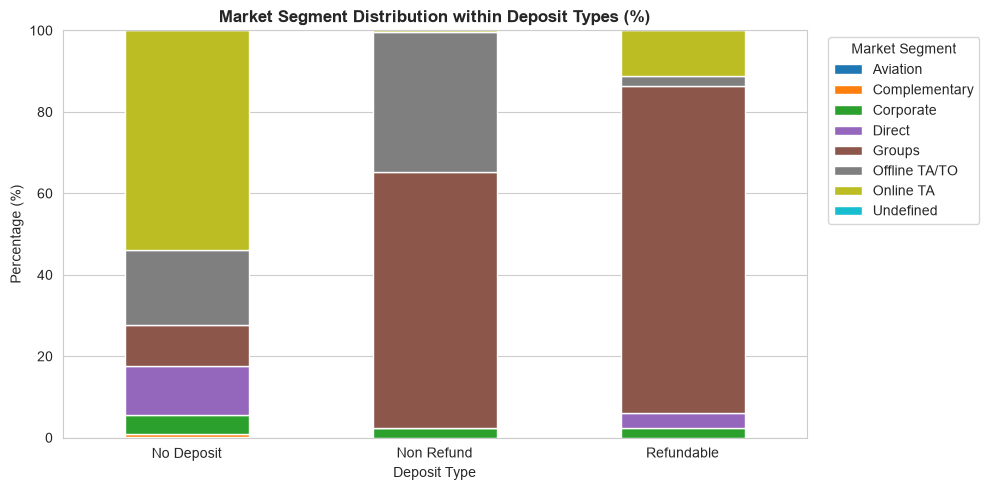

In [21]:
deposit_summary = df.groupby("deposit_type")["is_canceled"].agg(["count", "sum", "mean"])
deposit_summary["mean"] *= 100
deposit_summary.columns = ["Total Bookings", "Total Canceled", "Cancellation Rate (%)"]
print(deposit_summary.round(2))

nr_segment = df[df["deposit_type"] == "Non Refund"]["market_segment"].value_counts()
print(nr_segment)


# Market segment mix within each deposit type
ct = pd.crosstab(df["deposit_type"], df["market_segment"], normalize="index") * 100
ax = ct.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="tab10", edgecolor="white")
plt.title("Market Segment Distribution within Deposit Types (%)", fontweight="bold", fontsize=12)
plt.ylabel("Percentage (%)")
plt.xlabel("Deposit Type")
plt.xticks(rotation=0)
plt.legend(title="Market Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### CORRELATION HEATMAP

is_canceled                       1.000000
lead_time                         0.293123
previous_cancellations            0.110133
adults                            0.060017
days_in_waiting_list              0.054186
adr                               0.047557
stays_in_week_nights              0.024765
arrival_date_year                 0.016660
arrival_date_week_number          0.008148
children                          0.005048
stays_in_weekend_nights          -0.001791
arrival_date_day_of_month        -0.006130
company                          -0.020642
babies                           -0.032491
previous_bookings_not_canceled   -0.057358
agent                            -0.083114
is_repeated_guest                -0.084793
booking_changes                  -0.144381
required_car_parking_spaces      -0.195498
total_of_special_requests        -0.234658
Name: is_canceled, dtype: float64


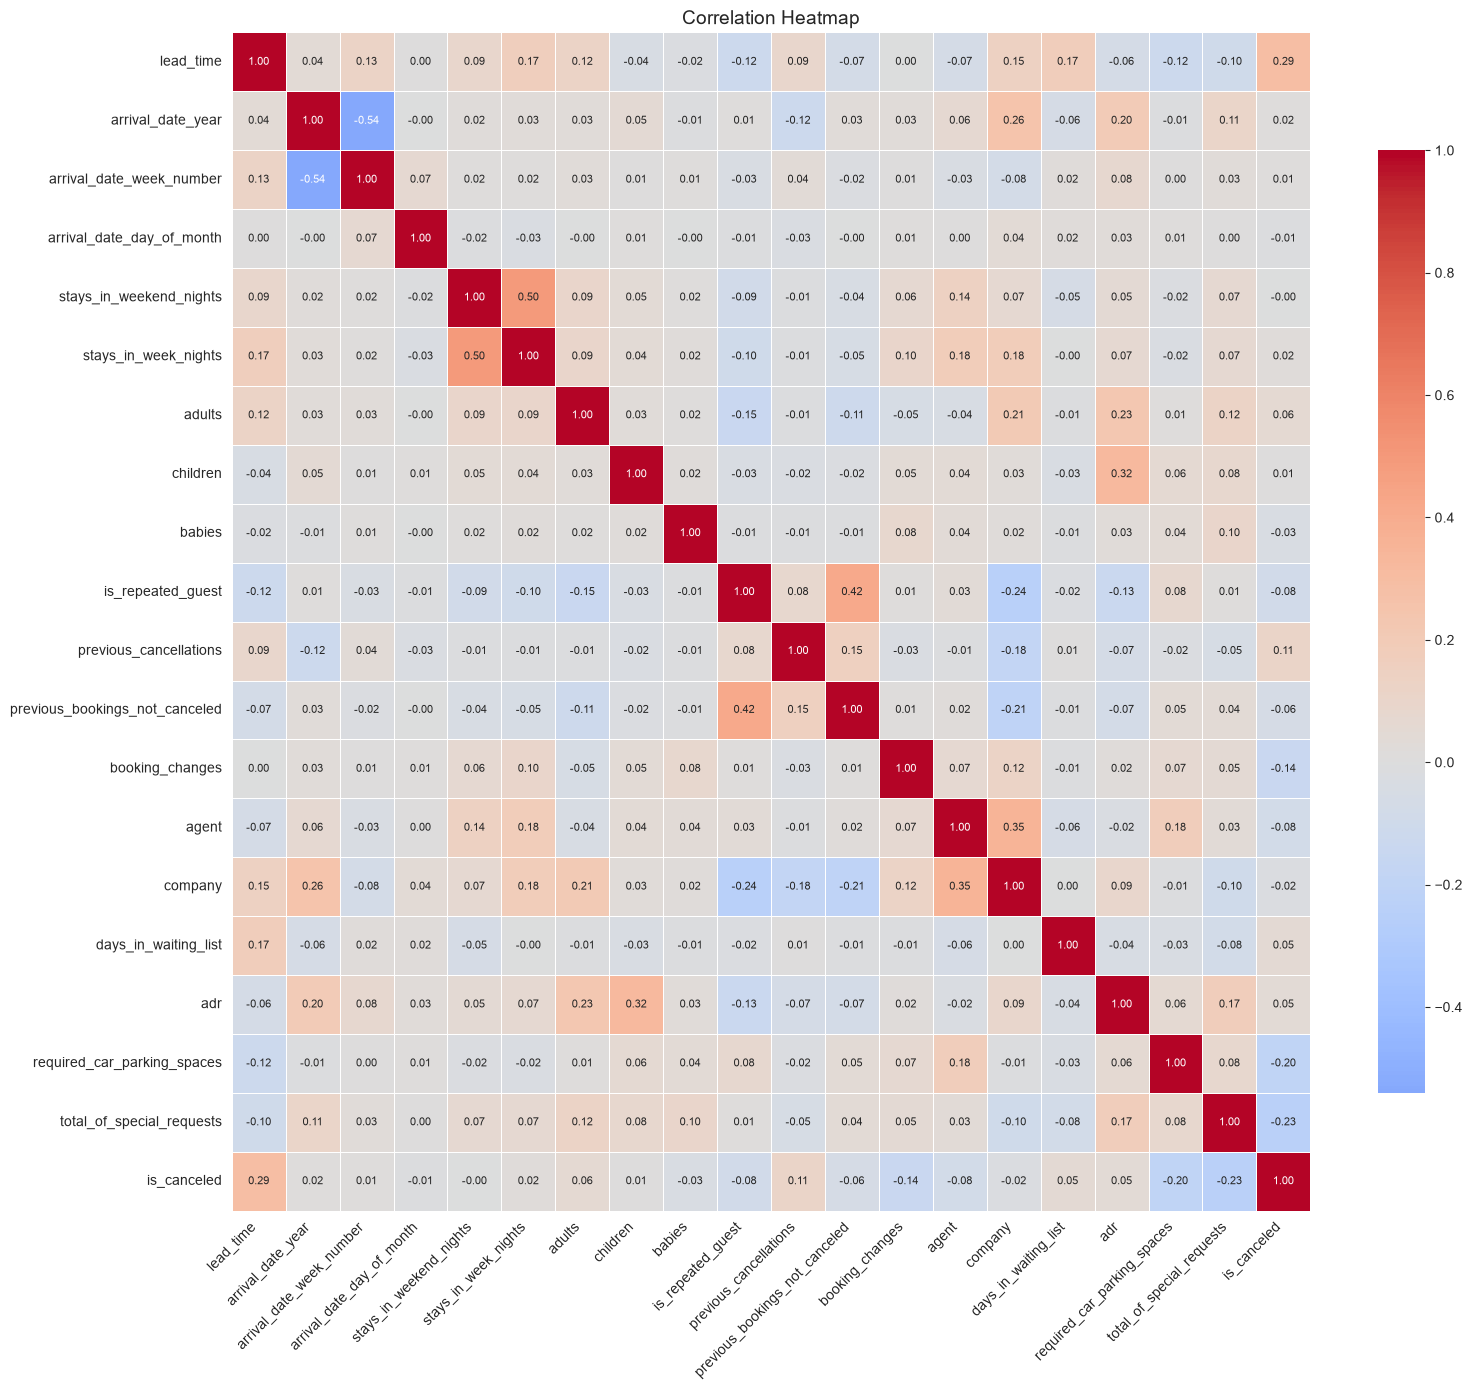

In [22]:
corr_matrix = df[numeric_cols + ["is_canceled"]].corr()
print(corr_matrix["is_canceled"].sort_values(ascending=False))

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### INVALID RECORDS

In [23]:
# Data-driven ADR upper threshold (99.9th percentile — avoids hardcoding)
adr_upper = df["adr"].quantile(0.999)
print(f"Data-driven ADR upper threshold (99.9th pct): {adr_upper:.2f} EUR")

zero_guests = ((df["adults"] + df["children"].fillna(0) + df["babies"]) == 0).sum()
zero_nights = ((df["stays_in_weekend_nights"] == 0) & (df["stays_in_week_nights"] == 0)).sum()
print("Zero guest rows:", zero_guests)
print("Zero night rows:", zero_nights)
print("Negative ADR rows:", (df["adr"] < 0).sum())
print(f"ADR > {adr_upper:.2f} rows (99.9th pct):", (df["adr"] > adr_upper).sum())


Data-driven ADR upper threshold (99.9th pct): 326.20 EUR
Zero guest rows: 180
Zero night rows: 715
Negative ADR rows: 1
ADR > 326.20 rows (99.9th pct): 120


### DATA LEAKAGE ANALYSIS

In [24]:
print(pd.crosstab(df["reservation_status"], df["is_canceled"]))

room_diff = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)
print(df.groupby(room_diff)["is_canceled"].agg(["count", "mean"]))

print(df.groupby(df["booking_changes"] > 0)["is_canceled"].agg(["count", "mean"]))
print(df.groupby(df["days_in_waiting_list"] > 0)["is_canceled"].agg(["count", "mean"]))

leakage_cols = ["reservation_status", "reservation_status_date",
                 "assigned_room_type", "booking_changes", "days_in_waiting_list"]

audit_data = []
for col in df.columns:
    if col == "is_canceled":
        cat, action = "Target Variable", "Predict"
    elif col in ["reservation_status", "reservation_status_date"]:
        cat, action = "Target Outcome Leakage", "Drop"
    elif col == "assigned_room_type":
        cat, action = "Operational Lookahead Leakage", "Drop"
    elif col == "booking_changes":
        cat, action = "Temporal Lookahead Leakage", "Drop"
    elif col == "days_in_waiting_list":
        cat, action = "Operational Queue Leakage", "Drop"
    else:
        cat, action = "Available at Booking Time", "Retain"
    audit_data.append({"Feature": col, "Category": cat, "Action": action})
audit_df = pd.DataFrame(audit_data)
print(audit_df["Category"].value_counts())
print(audit_df.to_string(index=False))

# =========================================================
# PREPROCESSING
# =========================================================


is_canceled             0      1
reservation_status              
Canceled                0  43017
Check-Out           75166      0
No-Show                 0   1207
    count      mean
0  104473  0.415629
1   14917  0.053764
                  count      mean
booking_changes                  
False            101314  0.408542
True              18076  0.156727
                       count      mean
days_in_waiting_list                  
False                 115692  0.361866
True                    3698  0.637912
Category
Available at Booking Time        26
Target Outcome Leakage            2
Target Variable                   1
Operational Lookahead Leakage     1
Temporal Lookahead Leakage        1
Operational Queue Leakage         1
Name: count, dtype: int64
                       Feature                      Category  Action
                         hotel     Available at Booking Time  Retain
                   is_canceled               Target Variable Predict
                     lead

# Part B — Preprocessing & Feature Engineering

### DATA CLEANING - remove invalid records

In [25]:
# adr_upper computed in the INVALID RECORDS diagnostic cell above
invalid_mask = (
    ((df["adults"] + df["children"].fillna(0) + df["babies"]) == 0) |
    ((df["stays_in_weekend_nights"] + df["stays_in_week_nights"]) == 0) |
    (df["adr"] < 0) |
    (df["adr"] > adr_upper)  
)
print(f"Dropping {invalid_mask.sum():,} invalid records")
df_clean = df[~invalid_mask].copy()


Dropping 946 invalid records


### REMOVE EXACT DUPLICATES

In [26]:
block_booking_segments = ["Groups", "Offline TA/TO", "Corporate"]

is_block_segment = df_clean["market_segment"].isin(block_booking_segments)
# keep='first' -> one copy of each duplicated booking survives (keep=False would delete ALL copies)
is_duplicate = df_clean.duplicated(keep="first")
is_duplicate_any = df_clean.duplicated(keep=False)

# Only drop exact duplicates OUTSIDE the block-booking segments
drop_mask = is_duplicate & ~is_block_segment

print(f"Duplicates dropped (non-block segments): {drop_mask.sum():,}")
print(f"Duplicates retained (likely genuine block bookings): {(is_duplicate_any & is_block_segment).sum():,}")

df_clean = df_clean[~drop_mask].copy()
print("Shape after cleaning:", df_clean.shape)

Duplicates dropped (non-block segments): 5,683
Duplicates retained (likely genuine block bookings): 30,341
Shape after cleaning: (112761, 32)


### REMOVE LEAKAGE COLUMNS

In [27]:
df_clean = df_clean.drop(columns=leakage_cols)
print("Remaining columns:", df_clean.columns.tolist())


Remaining columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'deposit_type', 'agent', 'company', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


### POST-LEAKAGE DUPLICATE-PREDICTOR CONFLICT CHECK

In [28]:
predictor_cols = [c for c in df_clean.columns if c != "is_canceled"]
dup_predictor_rows = df_clean[df_clean.duplicated(subset=predictor_cols, keep=False)]
print("Rows with duplicate predictor combinations:", len(dup_predictor_rows))

target_counts_per_group = dup_predictor_rows.groupby(predictor_cols, dropna=False)["is_canceled"].nunique()
conflicting_groups = target_counts_per_group[target_counts_per_group > 1]
print("Duplicate predictor groups with conflicting target values:", len(conflicting_groups))
print("Decision: retain these rows; conflicting outcomes prove they are distinct bookings.")
print("Leakage across train/test will be prevented via a group-aware split.")


Rows with duplicate predictor combinations: 33254
Duplicate predictor groups with conflicting target values: 302
Decision: retain these rows; conflicting outcomes prove they are distinct bookings.
Leakage across train/test will be prevented via a group-aware split.


### HIDDEN MISSING VALUE RECODING

In [29]:
df_clean["meal"] = df_clean["meal"].replace({"Undefined": "SC"})


### FEATURE ENGINEERING (row-wise, no dataset-level statistics)

In [30]:
df_clean["has_agent"] = df_clean["agent"].notna().astype(int)
df_clean["has_company"] = df_clean["company"].notna().astype(int)

df_clean["total_nights"] = df_clean["stays_in_weekend_nights"] + df_clean["stays_in_week_nights"]
df_clean["total_guests"] = df_clean["adults"] + df_clean["children"].fillna(0) + df_clean["babies"]
df_clean["is_family"] = ((df_clean["children"].fillna(0) + df_clean["babies"]) > 0).astype(int)
df_clean["adr_per_person"] = df_clean["adr"] / np.maximum(df_clean["total_guests"], 1)
df_clean["lead_time_log"] = np.log1p(df_clean["lead_time"])

# ---- adr_log (log1p transform for scale-sensitive models) ----
df_clean["adr_log"] = np.log1p(df_clean["adr"].clip(lower=0))

# ---- lead_time_band (ordinal bucketing adds interpretability for linear models) ----
df_clean["lead_time_band"] = pd.cut(
    df_clean["lead_time"],
    bins=[-1, 7, 30, 90, 180, np.inf],
    labels=["0_same_week", "1_1_4_weeks", "2_1_3_months", "3_3_6_months", "4_6plus_months"]
).astype(str)  # string so OrdinalEncoder accepts it cleanly

# ---- prev_cancellation_rate (Laplace-smoothed; smoother than raw count) ----
total_prev = df_clean["previous_cancellations"] + df_clean["previous_bookings_not_canceled"]
df_clean["prev_cancellation_rate"] = df_clean["previous_cancellations"] / (total_prev + 1)

df_clean["has_previous_cancellation"] = (df_clean["previous_cancellations"] > 0).astype(int)
df_clean["has_parking_space"] = (df_clean["required_car_parking_spaces"] > 0).astype(int)
df_clean["has_special_requests"] = (df_clean["total_of_special_requests"] > 0).astype(int)

month_map = {"January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
             "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12}
month_num = df_clean["arrival_date_month"].map(month_map)
df_clean["arrival_month_sin"] = np.sin(2 * np.pi * month_num / 12)
df_clean["arrival_month_cos"] = np.cos(2 * np.pi * month_num / 12)
df_clean["arrival_season"] = month_num.map({12: "Winter", 1: "Winter", 2: "Winter",
                                             3: "Spring", 4: "Spring", 5: "Spring",
                                             6: "Summer", 7: "Summer", 8: "Summer",
                                             9: "Autumn", 10: "Autumn", 11: "Autumn"})

print("Columns after feature engineering:", df_clean.shape[1])


Columns after feature engineering: 43


### SEPARATE PREDICTORS AND TARGET

In [31]:
X = df_clean.drop(columns=["is_canceled"]).copy()
y = df_clean["is_canceled"].astype(int).copy()
print("X shape:", X.shape, "y shape:", y.shape)


X shape: (112761, 42) y shape: (112761,)


### GROUP-AWARE, STRATIFIED TRAIN-TEST SPLIT

In [32]:
predictor_groups = pd.util.hash_pandas_object(X, index=False)

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=predictor_groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

train_groups = set(predictor_groups.iloc[train_idx])
test_groups = set(predictor_groups.iloc[test_idx])
overlap = len(train_groups.intersection(test_groups))

print(f"X_train: {X_train.shape[0]:,} rows ({len(train_idx)/len(X)*100:.2f}%) | cancellation rate: {y_train.mean():.4f}")
print(f"X_test:  {X_test.shape[0]:,} rows ({len(test_idx)/len(X)*100:.2f}%) | cancellation rate: {y_test.mean():.4f}")
print(f"Group overlap between train and test: {overlap}")


X_train: 90,209 rows (80.00%) | cancellation rate: 0.3675
X_test:  22,552 rows (20.00%) | cancellation rate: 0.3675
Group overlap between train and test: 0


### MISSING VALUE IMPUTATION

In [33]:
med_children = X_train["children"].median()
mode_market = X_train["market_segment"].mode()[0]
mode_channel = X_train["distribution_channel"].mode()[0]

def impute_missing(data):
    out = data.copy()
    out["children"] = out["children"].fillna(med_children)
    out["country"] = out["country"].fillna("Unknown")
    out["agent"] = out["agent"].fillna(0)
    out["company"] = out["company"].fillna(0)
    out["market_segment"] = out["market_segment"].replace({"Undefined": mode_market})
    out["distribution_channel"] = out["distribution_channel"].replace({"Undefined": mode_channel})
    return out

X_train = impute_missing(X_train)
X_test = impute_missing(X_test)
print("Remaining NaNs - train:", X_train.isna().sum().sum(), "test:", X_test.isna().sum().sum())


Remaining NaNs - train: 0 test: 0


### GROUP HIGH-CARDINALITY CATEGORIES (train-only)

In [34]:
top_countries = X_train["country"].value_counts().head(15).index.tolist()
top_agents = X_train[X_train["agent"] != 0]["agent"].value_counts().head(10).index.tolist()

def group_categories(data):
    out = data.copy()
    out["country_grouped"] = out["country"].apply(lambda x: x if x in top_countries else "Other")

    def map_agent(val):
        if val == 0:
            return "Direct"
        elif val in top_agents:
            return f"Agent_{int(val)}"
        return "Other_Agent"

    out["agent_grouped"] = out["agent"].apply(map_agent)
    drop_cols = ["country", "agent", "company", "arrival_date_month",
                 "arrival_date_year", "arrival_date_day_of_month"]
    return out.drop(columns=[c for c in drop_cols if c in out.columns])

X_train = group_categories(X_train)
X_test = group_categories(X_test)

cat_cols_final = ["hotel", "meal", "market_segment", "distribution_channel", "reserved_room_type",
                   "deposit_type", "customer_type", "country_grouped", "agent_grouped", "arrival_season"]
ordinal_cols_final = ["lead_time_band"]  # encoded with explicit order, not OHE
num_cols_final = [c for c in X_train.columns if c not in cat_cols_final and c not in ordinal_cols_final]


### ENCODING (fit on train only)

In [35]:
from sklearn.preprocessing import OrdinalEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe.fit(X_train[cat_cols_final])
encoded_cols = ohe.get_feature_names_out(cat_cols_final).tolist()

X_train_ohe = pd.DataFrame(ohe.transform(X_train[cat_cols_final]), columns=encoded_cols, index=X_train.index)
X_test_ohe = pd.DataFrame(ohe.transform(X_test[cat_cols_final]), columns=encoded_cols, index=X_test.index)

# ---- OrdinalEncoder for lead_time_band (preserves meaningful order) ----
BAND_ORDER = [["0_same_week", "1_1_4_weeks", "2_1_3_months", "3_3_6_months", "4_6plus_months"]]
ord_enc = OrdinalEncoder(categories=BAND_ORDER, handle_unknown="use_encoded_value", unknown_value=-1)
ord_enc.fit(X_train[ordinal_cols_final])

X_train_ord = pd.DataFrame(
    ord_enc.transform(X_train[ordinal_cols_final]),
    columns=ordinal_cols_final, index=X_train.index
)
X_test_ord = pd.DataFrame(
    ord_enc.transform(X_test[ordinal_cols_final]),
    columns=ordinal_cols_final, index=X_test.index
)

# Assemble tree-model feature matrix (numeric + ordinal-encoded + one-hot encoded)
X_train_tree = pd.concat([X_train[num_cols_final], X_train_ord, X_train_ohe], axis=1)
X_test_tree = pd.concat([X_test[num_cols_final], X_test_ord, X_test_ohe], axis=1)
print("Tree-model feature matrix (with lead_time_band):", X_train_tree.shape)


Tree-model feature matrix (with lead_time_band): (90209, 93)


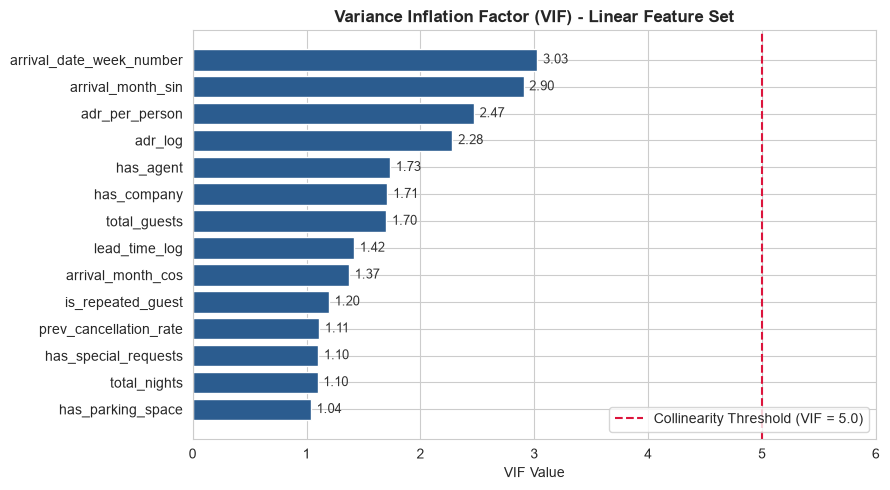

All features have VIF < 5 (max = 3.03), so there is no severe multicollinearity.


In [36]:
# VIF check on the non-redundant predictor subset used for linear/logistic modelling
linear_features = [
    'lead_time_log',
    'adr_log',
    'prev_cancellation_rate',
    'arrival_date_week_number',
    'total_nights',
    'total_guests',
    'is_repeated_guest',
    'adr_per_person',
    'has_parking_space',
    'has_special_requests',
    'has_agent',
    'has_company',
    'arrival_month_sin',
    'arrival_month_cos'
]

def compute_vif(frame):
    """VIF_j = 1 / (1 - R^2_j), where R^2_j comes from regressing feature j on all other features."""
    vifs = {}
    for col in frame.columns:
        others = frame.drop(columns=col)
        r2 = LinearRegression().fit(others, frame[col]).score(others, frame[col])
        vifs[col] = np.inf if r2 >= 1 - 1e-12 else 1.0 / (1.0 - r2)
    return pd.Series(vifs)

# lead_time_band is ordinal-encoded separately (not part of this numeric VIF check)
sample_X = X_train[linear_features].sample(min(5000, len(X_train)), random_state=42)
vif_df = (compute_vif(sample_X).rename("VIF").rename_axis("Feature").reset_index()
          .sort_values("VIF", ascending=True))

plt.figure(figsize=(9, 5))
bars = plt.barh(vif_df['Feature'], vif_df['VIF'], color='#2b5c8f')
plt.axvline(x=5.0, color='crimson', linestyle='--', linewidth=1.5, label='Collinearity Threshold (VIF = 5.0)')
plt.title("Variance Inflation Factor (VIF) - Linear Feature Set", fontsize=12, fontweight='bold')
plt.xlabel("VIF Value")
plt.legend(loc='lower right')
for bar in bars:
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.2f}",
             va='center', fontsize=9, color='#333333')
plt.xlim(0, max(6, vif_df['VIF'].max() * 1.15))
plt.tight_layout()
plt.show()

high_vif = vif_df[vif_df['VIF'] >= 5.0]
if high_vif.empty:
    print(f"All features have VIF < 5 (max = {vif_df['VIF'].max():.2f}), so there is no severe multicollinearity.")
else:
    print("Features at or above the VIF = 5 threshold (review before fitting a linear model):")
    print(high_vif.to_string(index=False))


### SCALING (winsorize + standardize, fit on train only, for linear/distance models)

In [37]:
p99_adr = X_train["adr"].quantile(0.99)

def winsorize(data):
    out = data.copy()
    out["adults"] = np.clip(out["adults"], 1, 4)
    out["children"] = np.clip(out["children"], 0, 3)
    out["babies"] = np.clip(out["babies"], 0, 2)
    out["adr"] = np.clip(out["adr"], 0, p99_adr)
    out["adr_per_person"] = np.clip(out["adr_per_person"], 0, p99_adr)
    # Recompute adr_log after winsorization so the transform reflects the clipped value
    out["adr_log"] = np.log1p(out["adr"].clip(lower=0))
    return out

# Ensure num_cols_final strictly contains numeric columns only
num_cols_final = [c for c in X_train.columns if c not in cat_cols_final and c not in ordinal_cols_final]

X_train_winsor = winsorize(X_train[num_cols_final])
X_test_winsor = winsorize(X_test[num_cols_final])

scaler = StandardScaler()
X_train_scaled_num = pd.DataFrame(scaler.fit_transform(X_train_winsor), columns=num_cols_final, index=X_train.index)
X_test_scaled_num = pd.DataFrame(scaler.transform(X_test_winsor), columns=num_cols_final, index=X_test.index)

X_train_scaled = pd.concat([X_train_scaled_num, X_train_ord, X_train_ohe], axis=1)
X_test_scaled = pd.concat([X_test_scaled_num, X_test_ord, X_test_ohe], axis=1)
print("Scaled feature matrix:", X_train_scaled.shape)


Scaled feature matrix: (90209, 93)


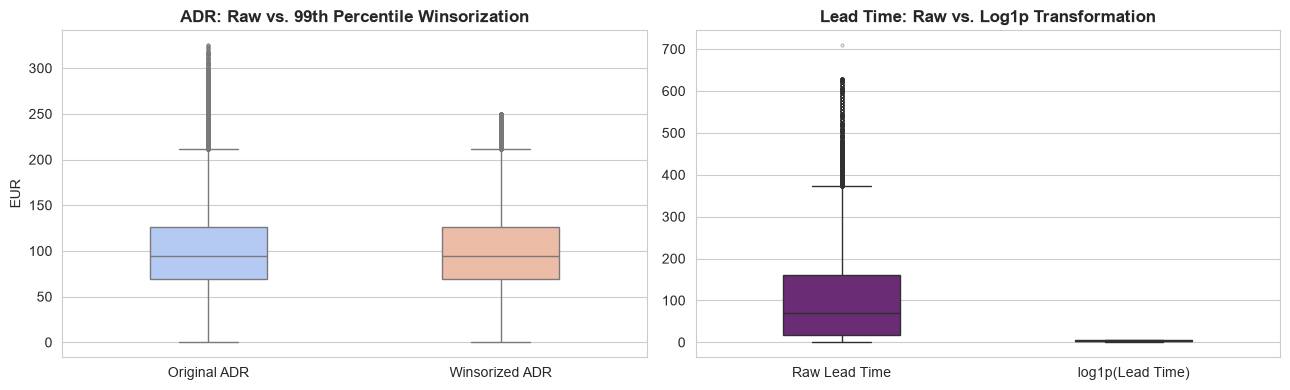

In [38]:
# Effect of winsorization and log transform
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 1. ADR Winsorization comparison
adr_comp = pd.DataFrame({"Original ADR": X_train["adr"], "Winsorized ADR": X_train_winsor["adr"]})
sns.boxplot(data=adr_comp, ax=axes[0], palette="coolwarm", width=0.4, flierprops=dict(markersize=2, alpha=0.3))
axes[0].set_title("ADR: Raw vs. 99th Percentile Winsorization", fontweight="bold")
axes[0].set_ylabel("EUR")

# 2. Lead Time Log1p Transformation
lead_comp = pd.DataFrame({"Raw Lead Time": df_clean["lead_time"], "log1p(Lead Time)": df_clean["lead_time_log"]})
sns.boxplot(data=lead_comp, ax=axes[1], palette="magma", width=0.4, flierprops=dict(markersize=2, alpha=0.3))
axes[1].set_title("Lead Time: Raw vs. Log1p Transformation", fontweight="bold")

plt.tight_layout()
plt.show()


### FEATURE IMPORTANCE CHECK

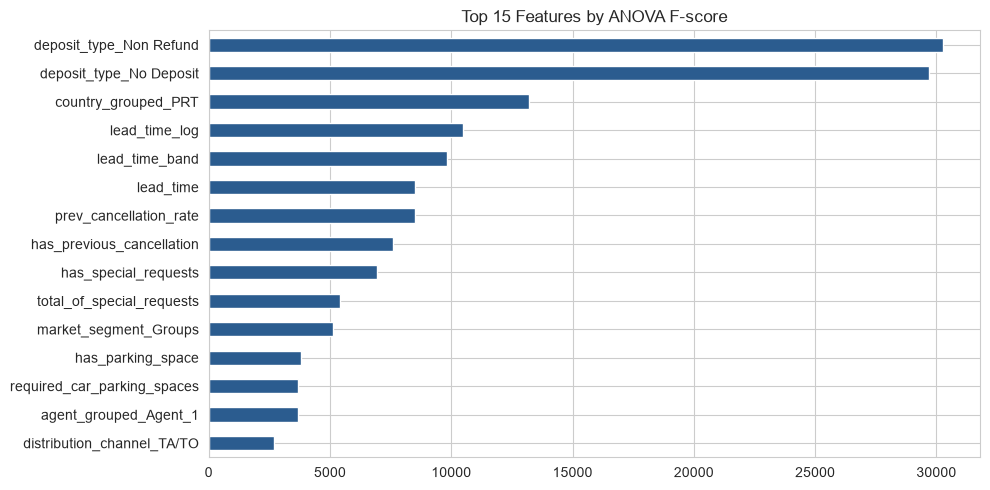

deposit_type_Non Refund      30283.740397
deposit_type_No Deposit      29705.839605
country_grouped_PRT          13187.816123
lead_time_log                10468.198224
lead_time_band                9819.569423
lead_time                     8507.459359
prev_cancellation_rate        8498.372958
has_previous_cancellation     7616.104064
has_special_requests          6923.135245
total_of_special_requests     5400.572166
dtype: float64


In [39]:
from sklearn.feature_selection import f_classif

f_scores, p_values = f_classif(X_train_tree, y_train)
feature_scores = pd.Series(f_scores, index=X_train_tree.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feature_scores.head(15).sort_values().plot(kind="barh", color="#2b5c8f")
plt.title("Top 15 Features by ANOVA F-score")
plt.tight_layout()
plt.show()

print(feature_scores.head(10))


### SAVE OUTPUTS

In [40]:
os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

X_train_tree.to_csv("data/X_train_tree.csv", index=False)
X_test_tree.to_csv("data/X_test_tree.csv", index=False)
X_train_scaled.to_csv("data/X_train_scaled.csv", index=False)
X_test_scaled.to_csv("data/X_test_scaled.csv", index=False)
y_train.to_csv("data/y_train.csv", index=False)
y_test.to_csv("data/y_test.csv", index=False)

print("Preprocessing complete.")


Preprocessing complete.


### CLASS IMBALANCE - SMOTE-RESAMPLED TRAINING SET (training data only)

The original, untouched files saved above are kept. This cell adds a **separate** balanced copy of the *scaled training set only*.

- `X_test_scaled.csv` / `y_test.csv` are never resampled; always evaluate on them (real-world class balance).
- Safe to use for fitting final models or a simple hold-out. For **cross-validation / hyper-parameter tuning**, do not use this file as the CV input (synthetic rows built from validation-fold neighbours would leak); resample inside each training fold instead.
- Tree models can use the original files with `class_weight` / `scale_pos_weight`.


In [41]:
def smote_nc(X, y, categorical_mask, k=5, random_state=42):
   
    rng = np.random.default_rng(random_state)
    counts = y.value_counts()
    minority_label = counts.idxmin()
    n_new = int(counts.max() - counts.min())

    cat_mask = np.asarray(categorical_mask, dtype=bool)
    num_idx, cat_idx = np.where(~cat_mask)[0], np.where(cat_mask)[0]
    X_min = X.loc[y == minority_label].to_numpy(dtype=float)

    penalty = np.median(X_min[:, num_idx].std(axis=0)) / np.sqrt(2)
    X_dist = np.hstack([X_min[:, num_idx], X_min[:, cat_idx] * penalty])
    neigh_full = NearestNeighbors(n_neighbors=k + 1).fit(X_dist).kneighbors(X_dist, return_distance=False)
    neigh = np.array([row[row != i][:k] for i, row in enumerate(neigh_full)])  # drop the row itself

    base = rng.integers(0, len(X_min), n_new)
    nbr = neigh[base, rng.integers(0, k, n_new)]
    gap = rng.random((n_new, 1))

    synth = X_min[base].copy()
    synth[:, num_idx] = X_min[base][:, num_idx] + gap * (X_min[nbr][:, num_idx] - X_min[base][:, num_idx])

    X_new = pd.DataFrame(synth, columns=X.columns)
    y_new = pd.Series(minority_label, index=X_new.index, name=y.name)
    X_out = pd.concat([X.reset_index(drop=True), X_new], ignore_index=True)
    y_out = pd.concat([y.reset_index(drop=True), y_new], ignore_index=True)
    order = rng.permutation(len(X_out))
    return X_out.iloc[order].reset_index(drop=True), y_out.iloc[order].reset_index(drop=True)


assert list(X_train_tree.columns) == list(X_train_scaled.columns)
binary_cols = X_train_tree.columns[X_train_tree.nunique() <= 2]
categorical_mask = X_train_scaled.columns.isin(binary_cols) | (X_train_scaled.columns == "lead_time_band")

print("Before SMOTE:")
print(y_train.value_counts().to_string())

X_train_scaled_smote, y_train_smote = smote_nc(X_train_scaled, y_train, categorical_mask, k=5, random_state=42)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts().to_string())
print(f"\nOriginal training rows: {len(X_train_scaled):,} | SMOTE-resampled training rows: {len(X_train_scaled_smote):,}")

# sanity checks: no NaNs, one-hot groups still valid, test set untouched
assert not X_train_scaled_smote.isna().any().any()
for prefix in ["hotel_", "meal_", "market_segment_", "agent_grouped_", "country_grouped_"]:
    group_cols = [c for c in X_train_scaled_smote.columns if c.startswith(prefix)]
    assert (X_train_scaled_smote[group_cols].sum(axis=1).round(6) == 1).all(), prefix
print("Sanity checks passed. Test set shape (unchanged):", X_test_scaled.shape)

X_train_scaled_smote.to_csv("data/X_train_scaled_smote.csv", index=False)
y_train_smote.to_csv("data/y_train_smote.csv", index=False)


Before SMOTE:
is_canceled
0    57058
1    33151

After SMOTE:
is_canceled
1    57058
0    57058

Original training rows: 90,209 | SMOTE-resampled training rows: 114,116
Sanity checks passed. Test set shape (unchanged): (22552, 93)


In [42]:
import pandas as pd
import numpy as np

# Load datasets
X_train = pd.read_csv("data/X_train_scaled.csv")
X_test = pd.read_csv("data/X_test_scaled.csv")
y_train = pd.read_csv("data/y_train.csv").values.ravel()
y_test = pd.read_csv("data/y_test.csv").values.ravel()

X_train_smote = pd.read_csv("data/X_train_scaled_smote.csv")
y_train_smote = pd.read_csv("data/y_train_smote.csv").values.ravel()

print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")
print(f"SMOTE Train Shape: {X_train_smote.shape}")
assert X_train.shape[1] == X_test.shape[1]
print("Data loaded successfully and shapes verified.")


Train Shape: (90209, 93) | Test Shape: (22552, 93)
SMOTE Train Shape: (114116, 93)
Data loaded successfully and shapes verified.


C:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Use

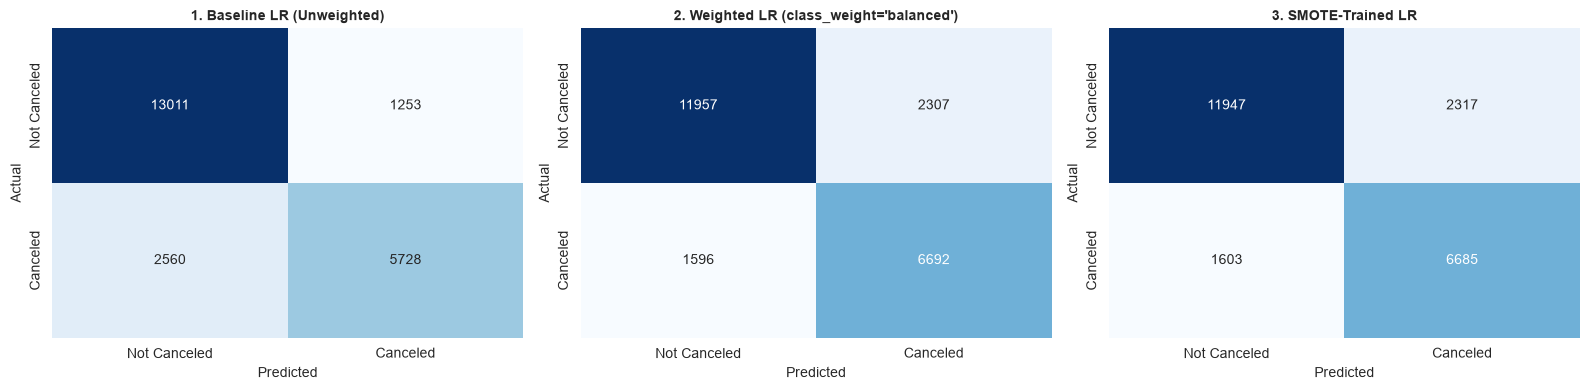


=== LOGISTIC REGRESSION: IMBALANCE STRATEGY COMPARISON ===
                                   Model  ROC-AUC  Macro F1  Cancellation Recall (Class 1)  Cancellation Precision (Class 1)  Accuracy
             1. Baseline LR (Unweighted)   0.9102    0.8112                         0.6911                            0.8205    0.8309
2. Weighted LR (class_weight='balanced')   0.9104    0.8170                         0.8074                            0.7436    0.8269
                     3. SMOTE-Trained LR   0.9103    0.8162                         0.8066                            0.7426    0.8262


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix

models = {
    "1. Baseline LR (Unweighted)": LogisticRegression(C=1.0, penalty="l2", solver="lbfgs", max_iter=1000, random_state=42),
    "2. Weighted LR (class_weight='balanced')": LogisticRegression(C=1.0, penalty="l2", solver="lbfgs", class_weight="balanced", max_iter=1000, random_state=42),
    "3. SMOTE-Trained LR": LogisticRegression(C=1.0, penalty="l2", solver="lbfgs", max_iter=1000, random_state=42)
}

results = []
trained_models = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (name, model) in enumerate(models.items()):
    if "SMOTE" in name:
        model.fit(X_train_smote, y_train_smote)
    else:
        model.fit(X_train, y_train)
    
    trained_models[name] = model
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    rep = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        "Model": name,
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
        "Macro F1": round(f1_score(y_test, y_pred, average="macro"), 4),
        "Cancellation Recall (Class 1)": round(rep["1"]["recall"], 4),
        "Cancellation Precision (Class 1)": round(rep["1"]["precision"], 4),
        "Accuracy": round(rep["accuracy"], 4)
    })
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[idx],
                xticklabels=["Not Canceled", "Canceled"], yticklabels=["Not Canceled", "Canceled"])
    axes[idx].set_title(name, fontsize=10, fontweight="bold")
    axes[idx].set_ylabel("Actual")
    axes[idx].set_xlabel("Predicted")

plt.tight_layout()
plt.show()

# Print comparison summary table
comparison_df = pd.DataFrame(results)
print("\n=== LOGISTIC REGRESSION: IMBALANCE STRATEGY COMPARISON ===")
print(comparison_df.to_string(index=False))


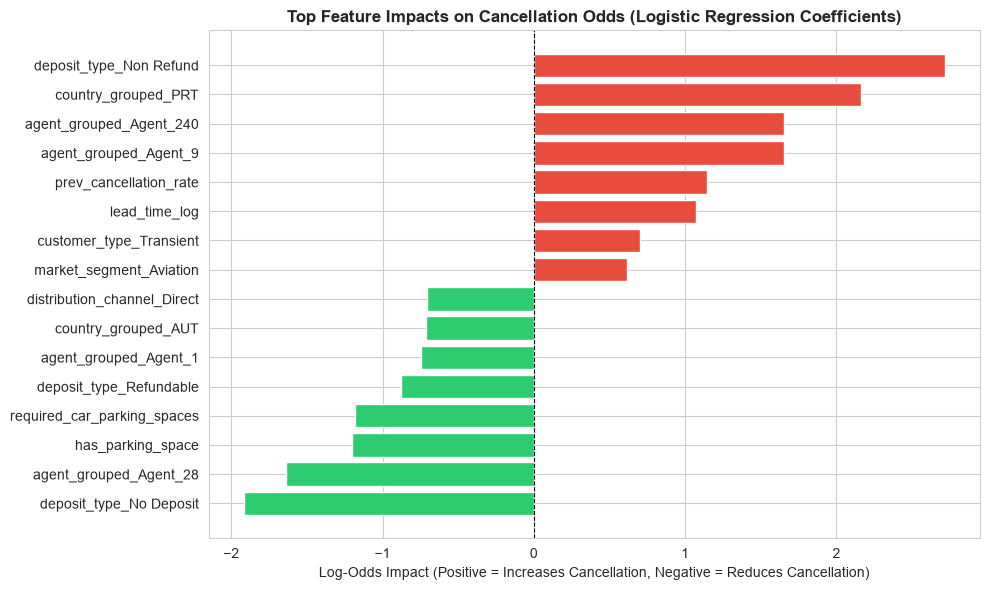

In [44]:
# Extract coefficients from the class-weighted model
best_lr = trained_models["2. Weighted LR (class_weight='balanced')"]

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_lr.coef_[0],
    "Odds_Ratio": np.exp(best_lr.coef_[0])
}).sort_values(by="Coefficient", ascending=False)

top_pos = coef_df.head(8)
top_neg = coef_df.tail(8)
plot_df = pd.concat([top_pos, top_neg]).sort_values(by="Coefficient")

plt.figure(figsize=(10, 6))
colors = ["#2ecc71" if x < 0 else "#e74c3c" for x in plot_df["Coefficient"]]
plt.barh(plot_df["Feature"], plot_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Top Feature Impacts on Cancellation Odds (Logistic Regression Coefficients)", fontsize=12, fontweight="bold")
plt.xlabel("Log-Odds Impact (Positive = Increases Cancellation, Negative = Reduces Cancellation)")
plt.tight_layout()
plt.show()


In [45]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "solver": ["lbfgs"],
    "class_weight": ["balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print(f"Optimal Regularization Strength (C): {grid_lr.best_params_['C']}")
print(f"Best Cross-Validation ROC-AUC: {grid_lr.best_score_:.4f}")

# Final Evaluation of the tuned model on the test set
final_lr = grid_lr.best_estimator_
final_prob = final_lr.predict_proba(X_test)[:, 1]
print(f"Test Set ROC-AUC with Tuned Model: {roc_auc_score(y_test, final_prob):.4f}")


Optimal Regularization Strength (C): 0.1
Best Cross-Validation ROC-AUC: 0.9121
Test Set ROC-AUC with Tuned Model: 0.9106


In [46]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Load the unscaled Tree datasets
X_train_tree = pd.read_csv("data/X_train_tree.csv")
X_test_tree = pd.read_csv("data/X_test_tree.csv")

# 2. Train an unconstrained baseline (often severely overfits) vs a constrained tree
dt_unconstrained = DecisionTreeClassifier(random_state=42)
dt_unconstrained.fit(X_train_tree, y_train)

dt_baseline = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)
dt_baseline.fit(X_train_tree, y_train)

# Check for overfitting: Train vs Test accuracy
print("--- Overfitting Diagnostic ---")
print(f"Unconstrained Tree - Train Accuracy: {dt_unconstrained.score(X_train_tree, y_train):.4f} | Test: {dt_unconstrained.score(X_test_tree, y_test):.4f} (Severe Overfitting!)")
print(f"Constrained Tree   - Train Accuracy: {dt_baseline.score(X_train_tree, y_train):.4f} | Test: {dt_baseline.score(X_test_tree, y_test):.4f} (Well-Regularized)")


--- Overfitting Diagnostic ---
Unconstrained Tree - Train Accuracy: 0.9947 | Test: 0.8154 (Severe Overfitting!)
Constrained Tree   - Train Accuracy: 0.8419 | Test: 0.8366 (Well-Regularized)


In [47]:
param_grid_dt = {
    "max_depth": [6, 8, 10, 12, 15],
    "min_samples_split": [20, 50, 100],
    "min_samples_leaf": [10, 20, 50],
    "criterion": ["gini", "entropy"],
    "class_weight": ["balanced"]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    scoring="roc_auc",
    cv=cv,          # Reusing 5-fold StratifiedKFold from earlier
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train_tree, y_train)

best_dt = grid_dt.best_estimator_
print(f"\nOptimal Hyperparameters: {grid_dt.best_params_}")
print(f"Best CV ROC-AUC: {grid_dt.best_score_:.4f}")

# Evaluate on test set
y_pred_dt = best_dt.predict(X_test_tree)
y_prob_dt = best_dt.predict_proba(X_test_tree)[:, 1]

print("\n=== Tuned Decision Tree Test Performance ===")
print(classification_report(y_test, y_pred_dt, target_names=["Not Canceled", "Canceled"]))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.4f}")
print(f"Test Macro F1: {f1_score(y_test, y_pred_dt, average='macro'):.4f}")


Fitting 5 folds for each of 90 candidates, totalling 450 fits

Optimal Hyperparameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 10, 'min_samples_split': 100}
Best CV ROC-AUC: 0.9312

=== Tuned Decision Tree Test Performance ===
              precision    recall  f1-score   support

Not Canceled       0.90      0.81      0.85     14264
    Canceled       0.72      0.85      0.78      8288

    accuracy                           0.83     22552
   macro avg       0.81      0.83      0.82     22552
weighted avg       0.84      0.83      0.83     22552

Test ROC-AUC: 0.9225
Test Macro F1: 0.8186


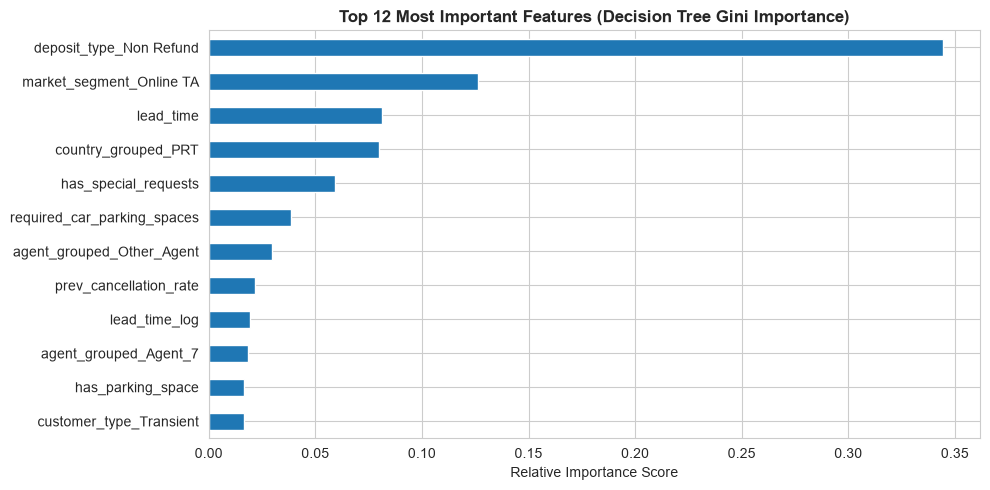

In [48]:
dt_importances = pd.Series(best_dt.feature_importances_, index=X_train_tree.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
dt_importances.head(12).sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 12 Most Important Features (Decision Tree Gini Importance)", fontsize=12, fontweight="bold")
plt.xlabel("Relative Importance Score")
plt.tight_layout()
plt.show()


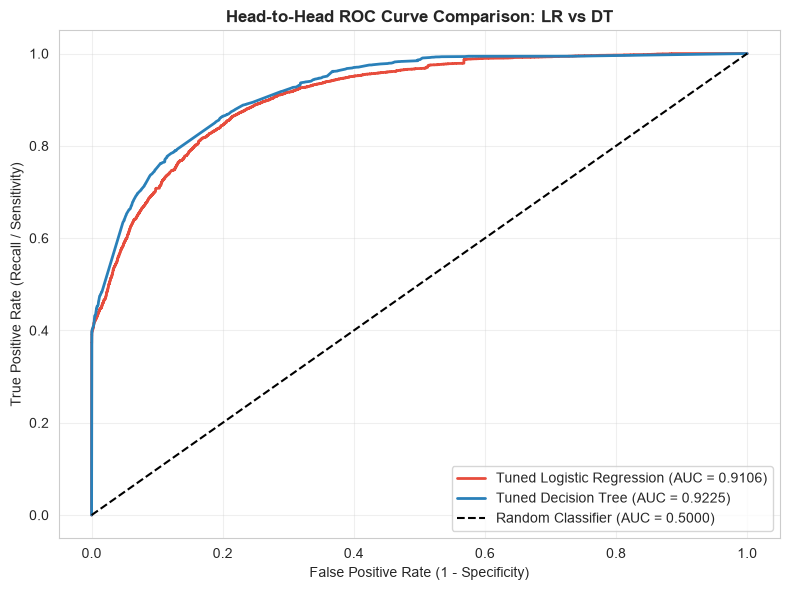


=== FINAL HEAD-TO-HEAD COMPARISON ===
                      Model  ROC-AUC  Macro F1  Class 1 Recall  Class 1 Precision  Accuracy
Logistic Regression (Tuned)   0.9106    0.8156          0.8042             0.7429    0.8258
      Decision Tree (Tuned)   0.9225    0.8186          0.8518             0.7234    0.8258


In [49]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

# 1. Compute ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, final_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

roc_auc_lr = roc_auc_score(y_test, final_prob)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

# 2. Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Tuned Logistic Regression (AUC = {roc_auc_lr:.4f})", color="#e74c3c", linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f"Tuned Decision Tree (AUC = {roc_auc_dt:.4f})", color="#2980b9", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier (AUC = 0.5000)")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall / Sensitivity)")
plt.title("Head-to-Head ROC Curve Comparison: LR vs DT", fontsize=12, fontweight="bold")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Summary Table
rep_lr = classification_report(y_test, final_lr.predict(X_test), output_dict=True)
rep_dt = classification_report(y_test, y_pred_dt, output_dict=True)

final_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression (Tuned)",
        "ROC-AUC": round(roc_auc_lr, 4),
        "Macro F1": round(f1_score(y_test, final_lr.predict(X_test), average="macro"), 4),
        "Class 1 Recall": round(rep_lr["1"]["recall"], 4),
        "Class 1 Precision": round(rep_lr["1"]["precision"], 4),
        "Accuracy": round(rep_lr["accuracy"], 4)
    },
    {
        "Model": "Decision Tree (Tuned)",
        "ROC-AUC": round(roc_auc_dt, 4),
        "Macro F1": round(f1_score(y_test, y_pred_dt, average="macro"), 4),
        "Class 1 Recall": round(rep_dt["1"]["recall"], 4),
        "Class 1 Precision": round(rep_dt["1"]["precision"], 4),
        "Accuracy": round(rep_dt["accuracy"], 4)
    }
])

print("\n=== FINAL HEAD-TO-HEAD COMPARISON ===")
print(final_comparison.to_string(index=False))


In [50]:
import joblib

joblib.dump(final_lr, "models/logistic_regression.joblib")
joblib.dump(best_dt, "models/decision_tree.joblib")
print("Saved both trained models into models/ folder.")


Saved both trained models into models/ folder.


## Gaussian Naive Bayes

In [51]:
import pandas as pd

X_train_nb = pd.read_csv("data/X_train_scaled_smote.csv")
y_train_nb = pd.read_csv("data/y_train_smote.csv").squeeze()

X_test_nb = pd.read_csv("data/X_test_scaled.csv")
y_test_nb = pd.read_csv("data/y_test.csv").squeeze()

print("X_train_nb shape:", X_train_nb.shape)
print("y_train_nb shape:", y_train_nb.shape)
print("X_test_nb shape:", X_test_nb.shape)
print("y_test_nb shape:", y_test_nb.shape)

X_train_nb shape: (114116, 93)
y_train_nb shape: (114116,)
X_test_nb shape: (22552, 93)
y_test_nb shape: (22552,)


In [52]:
from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()

gnb_model.fit(X_train_nb, y_train_nb)

print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


In [53]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_nb = gnb_model.predict(X_test_nb)

accuracy_nb = accuracy_score(y_test_nb, y_pred_nb)

print("Gaussian Naive Bayes Accuracy:", accuracy_nb)
print("\nClassification Report:")
print(classification_report(y_test_nb, y_pred_nb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_nb, y_pred_nb))

Gaussian Naive Bayes Accuracy: 0.5855799929052855

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.40      0.55     14264
           1       0.47      0.91      0.62      8288

    accuracy                           0.59     22552
   macro avg       0.68      0.65      0.58     22552
weighted avg       0.73      0.59      0.57     22552


Confusion Matrix:
[[5659 8605]
 [ 741 7547]]


### ROC-AUC Evaluation

In [54]:
from sklearn.metrics import roc_auc_score

y_prob_nb = gnb_model.predict_proba(X_test_nb)[:, 1]

roc_auc_nb = roc_auc_score(y_test_nb, y_prob_nb)

print("Gaussian Naive Bayes ROC-AUC:", roc_auc_nb)

Gaussian Naive Bayes ROC-AUC: 0.8207561388580914


### Save Gaussian Naive Bayes Model

In [55]:
import joblib

joblib.dump(gnb_model, "models/gaussian_naive_bayes.joblib")

print("Gaussian Naive Bayes model saved successfully.")

Gaussian Naive Bayes model saved successfully.


## LightGBM

In [56]:
import pandas as pd

X_train_lgbm = pd.read_csv("data/X_train_tree.csv")
y_train_lgbm = pd.read_csv("data/y_train.csv").squeeze()

X_test_lgbm = pd.read_csv("data/X_test_tree.csv")
y_test_lgbm = pd.read_csv("data/y_test.csv").squeeze()

print("X_train_lgbm shape:", X_train_lgbm.shape)
print("y_train_lgbm shape:", y_train_lgbm.shape)
print("X_test_lgbm shape:", X_test_lgbm.shape)
print("y_test_lgbm shape:", y_test_lgbm.shape)

X_train_lgbm shape: (90209, 93)
y_train_lgbm shape: (90209,)
X_test_lgbm shape: (22552, 93)
y_test_lgbm shape: (22552,)


In [57]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
import lightgbm as lgb

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.7.0


### Train LightGBM Model

In [59]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    objective="binary",
    random_state=42,
    scale_pos_weight=1.72
)

lgbm_model.fit(X_train_lgbm, y_train_lgbm)

print("LightGBM model trained successfully.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 33151, number of negative: 57058
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.100951 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1732
[LightGBM] [Info] Number of data points in the train set: 90209, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.367491 -> initscore=-0.542995
[LightGBM] [Info] Start training from score -0.542995
LightGBM model trained successfully.


### LightGBM Evaluation

In [60]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred_lgbm = lgbm_model.predict(X_test_lgbm)
y_prob_lgbm = lgbm_model.predict_proba(X_test_lgbm)[:, 1]

accuracy_lgbm = accuracy_score(y_test_lgbm, y_pred_lgbm)
roc_auc_lgbm = roc_auc_score(y_test_lgbm, y_prob_lgbm)

print("LightGBM Accuracy:", accuracy_lgbm)

print("\nClassification Report:")
print(classification_report(y_test_lgbm, y_pred_lgbm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_lgbm, y_pred_lgbm))

print("\nLightGBM ROC-AUC:", roc_auc_lgbm)

LightGBM Accuracy: 0.8522969137992196

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88     14264
           1       0.78      0.84      0.81      8288

    accuracy                           0.85     22552
   macro avg       0.84      0.85      0.84     22552
weighted avg       0.86      0.85      0.85     22552


Confusion Matrix:
[[12276  1988]
 [ 1343  6945]]

LightGBM ROC-AUC: 0.93745329471743


### Save LightGBM Model

In [61]:
import joblib

joblib.dump(lgbm_model, "models/lightgbm_model.joblib")

print("LightGBM model saved successfully.")

LightGBM model saved successfully.


In [62]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
import pandas as pd, joblib
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, f1_score

X_train_xgb = pd.read_csv("data/X_train_tree.csv")
y_train_xgb = pd.read_csv("data/y_train.csv").squeeze()
X_test_xgb = pd.read_csv("data/X_test_tree.csv")
y_test_xgb = pd.read_csv("data/y_test.csv").squeeze()

spw = (y_train_xgb == 0).sum() / (y_train_xgb == 1).sum()
print(f"scale_pos_weight = {spw:.2f}")

param_dist_xgb = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [4, 6, 8, 10],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 1, 5],
    "reg_lambda": [1, 5, 10],
}

search_xgb = RandomizedSearchCV(
    XGBClassifier(objective="binary:logistic", scale_pos_weight=spw, eval_metric="auc",
                  tree_method="hist", random_state=42, n_jobs=1),
    param_distributions=param_dist_xgb, n_iter=20, scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=1,
)
search_xgb.fit(X_train_xgb, y_train_xgb)
best_xgb = search_xgb.best_estimator_
print(search_xgb.best_params_, f"CV ROC-AUC: {search_xgb.best_score_:.4f}")

y_pred_xgb = best_xgb.predict(X_test_xgb)
y_prob_xgb = best_xgb.predict_proba(X_test_xgb)[:, 1]
print(classification_report(y_test_xgb, y_pred_xgb, target_names=["Not Canceled", "Canceled"]))
print(f"Test ROC-AUC: {roc_auc_score(y_test_xgb, y_prob_xgb):.4f}")
print(f"Test Macro F1: {f1_score(y_test_xgb, y_pred_xgb, average='macro'):.4f}")

joblib.dump(best_xgb, "models/xgboost_model.joblib")

scale_pos_weight = 1.72
Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'subsample': 0.7, 'reg_lambda': 5, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0} CV ROC-AUC: 0.9508
              precision    recall  f1-score   support

Not Canceled       0.90      0.87      0.89     14264
    Canceled       0.79      0.84      0.81      8288

    accuracy                           0.86     22552
   macro avg       0.85      0.85      0.85     22552
weighted avg       0.86      0.86      0.86     22552

Test ROC-AUC: 0.9426
Test Macro F1: 0.8504


['models/xgboost_model.joblib']

In [65]:
import pandas as pd, joblib
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import classification_report, roc_auc_score, f1_score

X_train_svm = pd.read_csv("data/X_train_scaled.csv")
y_train_svm = pd.read_csv("data/y_train.csv").squeeze()
X_test_svm = pd.read_csv("data/X_test_scaled.csv")
y_test_svm = pd.read_csv("data/y_test.csv").squeeze()

X_sub_svm, _, y_sub_svm, _ = train_test_split(
    X_train_svm, y_train_svm, train_size=20000, stratify=y_train_svm, random_state=42)

grid_svm = GridSearchCV(
    SVC(kernel="rbf", class_weight="balanced", cache_size=1000),
    param_grid={"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1]},
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1, verbose=1,
)
grid_svm.fit(X_sub_svm, y_sub_svm)
print(grid_svm.best_params_, f"CV ROC-AUC (subsample): {grid_svm.best_score_:.4f}")

svm_model = SVC(kernel="rbf", class_weight="balanced", cache_size=1000, **grid_svm.best_params_)
svm_model.fit(X_train_svm, y_train_svm)   # several minutes on 90k rows

y_pred_svm = svm_model.predict(X_test_svm)
y_score_svm = svm_model.decision_function(X_test_svm)
print(classification_report(y_test_svm, y_pred_svm, target_names=["Not Canceled", "Canceled"]))
print(f"Test ROC-AUC: {roc_auc_score(y_test_svm, y_score_svm):.4f}")
print(f"Test Macro F1: {f1_score(y_test_svm, y_pred_svm, average='macro'):.4f}")

joblib.dump(svm_model, "models/svm_model.joblib")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
{'C': 10, 'gamma': 0.01} CV ROC-AUC (subsample): 0.9213
              precision    recall  f1-score   support

Not Canceled       0.90      0.85      0.88     14264
    Canceled       0.77      0.84      0.80      8288

    accuracy                           0.85     22552
   macro avg       0.83      0.85      0.84     22552
weighted avg       0.85      0.85      0.85     22552

Test ROC-AUC: 0.9305
Test Macro F1: 0.8382


['models/svm_model.joblib']